## 🟢 이미지를 읽어서 ndarray로 바꾸기

(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)
(80, 80, 3)


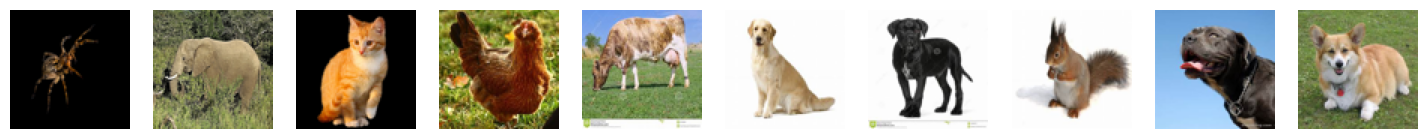

In [ ]:
import numpy as np
from PIL import Image
import os  # 파이썬에서 os 명령어를 사용할 수 있게 해준다.
            # 디렉토리 검색해서 해당 디렉토리의 파일 목록을 통째로 가져오는 명령어
import matplotlib.pyplot as plt   # 이미지 출력을 위한 라이브러리


# 🟢 우리는 지금 4차원, 3차원 이미지가 여러장이기때문에 이 이미지를 2차원 ndarray로 바꾸는 작업을 하는 것이다.
# 몇개의 애니멀 사진을 가지고 와서 numpy 배열(ndarray)로 만들고, npz 파일로 저장할 것!!!
# (340, 514, 3) => 340 x 514 x 3 크기의 이미지
# 이미지 크기를 줄여서 파일로 만드는 방법

path = "./.data/animal"
filenameList = os.listdir(path)   # 해당 경로에 있는 모든 파일을 읽어서 파일 목록을 전달해준다.
# print(filenameList)

# 🔥 본격적인 작업 돌입
imageList = []
for filename in filenameList:
    if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".gif")):
        continue

    filepath = os.path.join(path, filename)
    temp = Image.open(filepath).convert("RGB")

    # 이미지 크기 축소
    img = temp.resize((80, 80))  # tuple 형식으로 줘야한다. 
    img = np.array(img) # 이미지를 ndarray로 바꾸기
    print(img.shape)

    # 리스트에 추가하자!
    imageList.append(img)


# 🔥 저장하기
np.savez("data1.npz", data=imageList)

# 저장한 파일을 불러오기
data1 = np.load("data1.npz")["data"]
plt.figure(figsize=(20, 5))

# 화면에 출력하기
for i in range(1, len(data1)+1):
    plt.subplot(1, 11, i)  # 차트의 공간을 1 by 10개로 나누고, 1부터 번호 시작
    plt.imshow(data1[i-1])  # 이미지 표시
    plt.axis("off")  # 축 비활성화
plt.show()





## 🟢 꽃 분류하기 문제 풀어보기

- flower.zip
- 압축을 풀면 daisy, dandalion, rose, sunflower, tulip 이 있겠지
- 이것들로 머신러닝을 하고 싶은 것입니다.

- 입력데이터는 무조건 2D, 라벨링은 1D  /  폴더별로 0, 1, 2, 3, 4 

- 라벨링 작업을 해야합니다.


아래 작성된된 코드는 **꽃 이미지 분류를 위한 데이터 전처리 함수**입니다.  
구체적으로 설명하면:

## 코드의 주요 과정:

1. **이미지 데이터 수집 및 전처리**: 
   - 지정된 폴더에서 이미지 파일들을 읽어옵니다
   - 이미지 파일 형식 검증 (gif, png, jpg, jpeg만 허용)
   - 모든 이미지를 80x80 크기로 리사이즈하여 통일

2. **라벨링 작업**:
   - 각 폴더별로 숫자 라벨을 부여 (예: daisy=0, dandelion=1, rose=2 등)
   - 이미지 데이터와 해당 라벨을 매칭

3. **데이터 변환**:
   - PIL 이미지를 numpy 배열로 변환
   - RGB 3채널 이미지만 처리 (80x80x3 형태)



In [ ]:
import numpy as np
import os
import PIL.Image as pilimag
import imghdr                   # 이미지의 종류를 알아내고자 할 때 사용
import pandas as pd

# makeData => 폴더명하고 라벨을 주면 makeData("daisy", 1)
# 해당 폴더 데이터 쭉 읽어서 numpy 배열로 바꾸고 라벨링 작업도 하고

def makeData(folder, label):
    data = []       # 이미지의 피처를 저장 - 마지막에 둘다 반환하기
    labels = []     # 라벨을 저장
    path = "./.data/flowers/" + "/" + folder
    
    for filename in os.listdir(path):
        try:
            print(path + "/" + filename)
            kind = imghdr.what(path + "/" + filename)
            if kind in ["gif", "png", "jpg", "jpeg"]:  # 이 이미지에 해당되면
                img = pilimag.open(path + "/" + filename)
                # 이미지 크기가 다르면 분석 불가능, 동일한 이미지 크기로 해얗나다.
                # 그리고 이미지 크기가 너무 크면 학습할 때 픽처 개수만 너무 많아서 학습이 어렵다.
                # 적당한 크기로 잘라야 한다.

                resize_img = img.resize((80, 80))  # 이미지 크기가 다르면 분석 불간, 동일한 이미지 크기로 해야한다.
                pixel = np.array(resize_img)       # 이미지를 => ndarray로 바꾸기

                if pixel.shape == (80, 80, 3):     # 이미지 크기 같은 것만 취급한다.
                    data.append(pixel)
                    labels.append(label)

        except:
            print(filename + " error ")        # 어떤 파일이 에러인지 찾아서 직접 삭제 시키기 위함.

    # 파일로 정장하기
    np.savez("{}.npz".format(folder), data = data, target=labels)

# 1. 파일로 저장하기
def file_save():
    makeData("daisy", "0")
    makeData("dandelion", "1")
    makeData("sunflower", "2")
    makeData("rose", "3")
    makeData("tulip", "4")

# 2. 파일 불러오기
def file_load():
    daisy = np.load("daisy.npz")  # 파일 불러오기
    dandelion = np.load("dandelion.npz")  # 파일 불러오기
    sunflower = np.load("sunflower.npz")  # 파일 불러오기
    rose = np.load("rose.npz")  # 파일 불러오기
    tulip = np.load("tulip.npz")  # 파일 불러오기
    
    # 데이터 합치기
    data = np.concatenate((daisy["data"], 
                          dandelion["data"], 
                          sunflower["data"], 
                          rose["data"], 
                          tulip["data"]))
    
    # 라벨링 합치기
    target = np.concatenate((daisy["target"], 
                            dandelion["target"], 
                            sunflower["target"], 
                            rose["target"], 
                            tulip["target"]))

    print(data.shape)
    print(target.shape)

    # 데이터 프레임 만들기
    return data, target

data, target = file_load()
data = data.reshape(data.shape[0], 80*80*3)
# 차원을 그대로 받아들인다.
print(data.shape)

# 머신러닝의 일부 알고리즘과 딥러닝은 반드시 정규화 또 스케일링 0~1 사이으이 값으로 축소시키는 것이 유리함
data = data / 255.0

# ================================================
# 데이터 분리 
# 데이터 분리는 왜 하는 것일까???
# = 데이터 분리는 모델이 처음 보는 새로운 데이터에서도 잘 작동하는지 공정하게 평가하기 위해서 꼭 필요합니다.
# = 과적합을 막고, 일반화 성능을 측정하기 위해서입니다.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.5, random_state=0)

# ================================================
# knn 알고리즘 사용
print("\n------- knn 알고리즘 사용 -------")
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train, y_train)
print(f"훈련셋 : {model.score(x_train, y_train)}")
print(f"테스트셋 : {model.score(x_test, y_test)}")

# ================================================
# 그라이던트부스트
# print("\n------- 그라이던트부스트 -------")
# from sklearn.ensemble import GradientBoostingClassifier



(4317, 80, 80, 3)
(4317,)
(4317, 19200)

------- knn 알고리즘 사용 -------
훈련셋 : 0.5301204819277109
테스트셋 : 0.3209819360815192
